# Netflix Titles EDA

In [73]:
# Import the necessary EDA libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [74]:
# Read the dataset as a pandas dataframe "df"

df = pd.read_csv('netflix_titles.csv')

In [75]:
# Explore the dataset to understand its structure, datatypes, and content

df.shape

(8807, 12)

In [76]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


**The dataset contains 8,807 Netflix titles and 12 variables covering type of content, title, contributors, geography, catalog-addition date, release year, rating, duration, genre, and description. Each row represents one title, so the data is structured appropriately for title-level comparisons.**






In [47]:
# Check for missing values in the dataset

df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

 **The `director` column has highest number of missing values, followed by `country` and `cast`. Other columns, including `date_added`, `rating`, and `duration`, contain only a small number of missing values, while the remaining columns are complete.**

 **Missing values are more concentrated in descriptive columns rather than across the entire dataset. The rows were retained to preserve the dataset size, as removing records with missing director would exclude almost one-third of the data. Missing values were handled based on the requirements of each analysis.** 

**Incomplete information in fields such as director, country, and cast may affect analyses involving creators, production regions, or actors.**

In [49]:
# Use value_counts() to get the count how many movies and tv shows exist in the type column
  
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

**Movies represent the majority of titles in the dataset, with 6,131 entries compared to 2,676 TV shows out of 8,807 total titles.**
**This indicates that Netflix's content library in this dataset has a stronger representation of film content compared to episodic content.**

**This comparison reflects the distribution of titles in the catalog and does not indicate differences in popularity, viewing hours, or audience preference between movies and TV shows.**

In [51]:
# Check the top 10 countries with the most titles in the dataset using value_counts() and head()

df['country'].value_counts().head(10)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

**The United States has the highest number of titles in the dataset, followed by India and the United Kingdom.** 

**This suggests that Netflix's catalog is strongly represented by U.S. content while also maintaining a substantial international presence fron European and Asian markets. However, these figures reflect catalog representation rather than production volume or viewer demand.** 

**The `country`column contains multiple countries in some records and missing values, so these counts do not necessarily represent individual production countries. Splitting and normalizing these entries would provide a more reliable analysis or regional content distribution.**

In [77]:
# Check the top 10 content ratings in the dataset using value_counts() and head()

df['rating'].value_counts().head(10)

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

**TV-MA (3,207 titles) and TV-14 (2,160) are the two most common ratings in the dataset, together accounting for approximately 60.9% of all titles in the dataset. This indicates a strong representaion of content classified for mature and teenage audiences.**

**However, ratings should be examined separately for movies and TV shows because classification patterns differ between content types.**

In [78]:
# Check the latest and earliest release years in the dataset using max() and min() functions on the release_year column

latest_release_year = df['release_year'].max()

earliest_release_year = df['release_year'].min()

print(latest_release_year)
print(earliest_release_year)

2021
1925


**Release years range from 1925 to 2021, covering a 96-year span of both archival and contemporary content. The `release_year` column represents the original release date of titles, which differs from when content was added to Netflix.**

**Therefore, `release_year` is used to analyze content age and library depth, while `date_added` is reserved for examining catalog growth over time.**

In [ ]:
# Convert the date_added column to datetime format using pd.to_datetime

# Use errors='coerce' to replace any invalid or malformed date values with NaT, allowing the conversion to complete

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

**The `date_added` column was converted from text to a datetime format to enable accurate time-based analysis and  chronological grouping. Missing or invalid dates were converted to `NaT` using errors='coerce', allowing data quality issues to be identified without interrupting the workflow.**

**Subsequent time-based analyses use only records with valid catalog addition dates.** 

In [82]:
# Create year_added, month_added, and day_added columns by extracting the year, month, and day from the date_added column using the .dt accessor

df['year_added'] = df['date_added'].dt.year

df['month_added'] = df['date_added'].dt.month

df['day_added'] = df['date_added'].dt.day

**The `year_added`, `month_added`, and `day_added` columns were created from `date_added` to simplify time-based analysis. These derived features enable annual, monthly, and daily trend analysis while preserving missing values from the original column.**

In [85]:
# Create a main_genre column by taking the first genre from the listed_in column, using .str accessor.

df['main_genre'] = df['listed_in'].str.split(',').str[0]

**The `listed_in` column contains multiple comma-separated genres for many titles. Extracting the first genre creates a single `main_genre` for each record, making high-level comparisons and visualizations more straightforward. Since secondary genres are not included, this feature is intended for summary analysis only.** 

**A more comprehensive genre analysis would require splitting and expanding all listed genres.**

In [ ]:
# Extract numeric duration in minutes from movies only, into a new column called duration_minutes, using regex to extract the numeric part and convert it float.

# Extract numeric duration from movies only
# Use regex to extract the numeric part, since the 'duration' column contains values like '90 min', then convert to integer

df['duration_minutes'] = df['duration'].str.extract(r'(\d+)').astype(float)

**The `duration` column contains two different measurements: movie lengths in minutes, while TV show duration in seasons. Extracting the numeric portion for movies creates a consistent quantitative variable for runtime analysis while avoiding comparisons between incompatible units.**

**TV show duration require a separate feature, such as number of seasons, and should be anlyzed independently.**

## EDA and Visualization

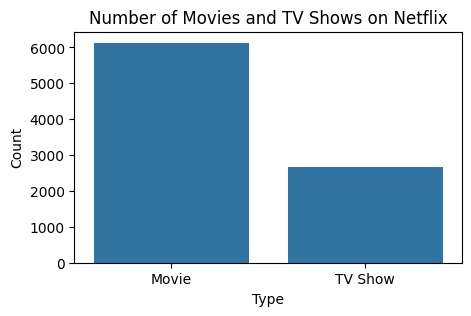

In [86]:
# Create a visualization to show the distribution of movies and tv shows on Netflix using seaborn's countplot function.

plt.figure(figsize=(5, 3))            # Set the figure size - width, height in inches

sns.countplot(data=df,x='type')
plt.title('Number of Movies and TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')

plt.show()

**The visualization shows a clear imbalance between content formats, with movies representing 69.6% of titles and TV shows accounting for 30.4%. The movie catalog is approximately 2.3 times larger than the TV show catalog, establishing an important baseline for subsequent analyses.**

**Comparisons between formats should consider this imbalance, as raw counts will naturally favor movies due to their larger representation.**

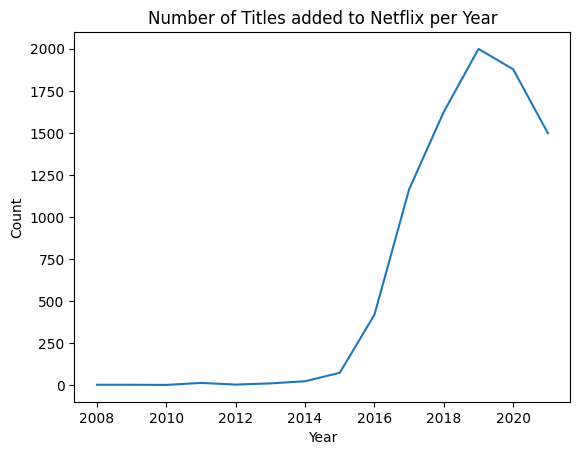

In [88]:
# Create a visualization to show the number of titles added to Netflix per year using seaborn's lineplot function

# Count how many titles were added per year
year_counts = df['year_added'].value_counts()

# Convert into proper DataFrame then plot with seaborn line plot
year_counts_df = year_counts.reset_index()
year_counts_df.columns = ['year', 'count']
year_counts_df = year_counts_df.sort_values('year')

# Plot the line plot using seaborn
sns.lineplot(data=year_counts_df, x='year', y='count')
plt.title('Number of Titles added to Netflix per Year')
plt.xlabel('Year')
plt.ylabel('Count')

plt.show()


**The number of titles added to Netflix increased sharply after 2015, increasing from 82 titles in 2015 to a peak of 2,016 titles in 2019. The period between 2016 and 2019 represents the strongest catalog expansion in the dataset. This trend reflects Netflix catalog additions rather than content production trends.**

**Although additions declined in 2020 and 2021, the decrese in 2021 should be interpreted cautiously, as the dataset snapshot may not represent a complete year.**


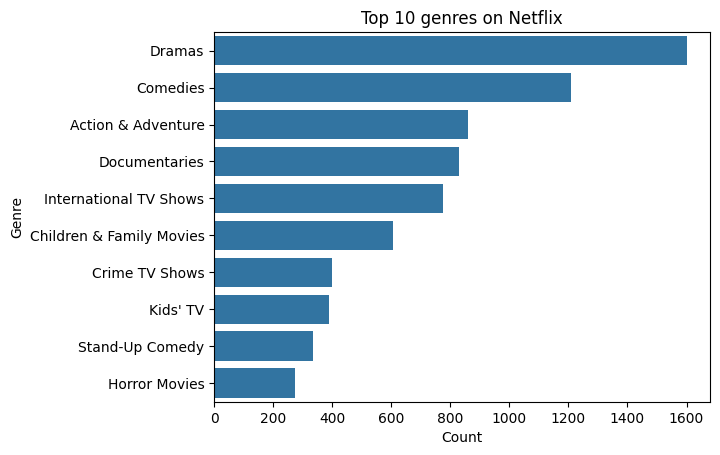

In [91]:
# Create a visualization to show the top 10 genres on Netflix using seaborn's barplot function


# Count genres and select the top 10
top_genres = df['main_genre'].value_counts().head(10)

# Convert new variable into DataFrame 
top_genres_df = top_genres.reset_index()
top_genres_df.columns = ['genre', 'count']

# Plot the barplot using seaborn
sns.barplot(data=top_genres_df, x='count', y='genre')
plt.title('Top 10 genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')

plt.show()


**Drama is the most common first listed genre in the dataset with 1,600 titles, followed by Comedy (1,210), Action & Adventure (859), and Documentaries (829). These results provide a high-level view of genre representation, but they are based only on the first listed genre assigned to each title.** 

**A complete genre distribution analysis would require splitting and expanding all genre labels. Additionally, these counts represent catalog availability rather than audience preferences, popularity, or performance.**

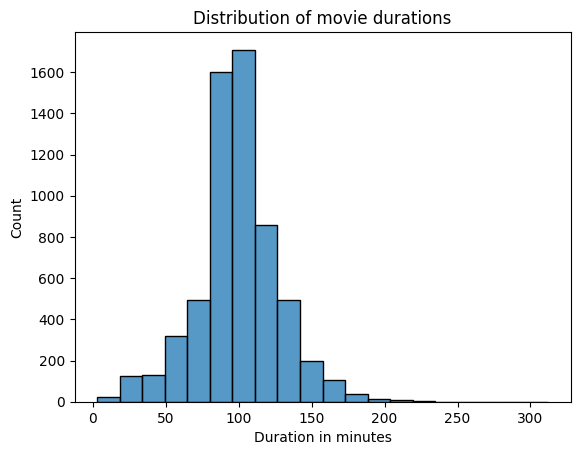

In [92]:
# Create a visualization to show the distribution of movie durations on Netflix using seaborn's histplot function

# Filter the DataFrame to include only movies
Movies = df[df['type'] == 'Movie']

# Plot the histogram of movie durations using seaborn's histplot function
sns.histplot(data=Movies, x='duration_minutes', bins=20)

plt.title('Distribution of movie durations')
plt.xlabel('Duration in minutes')
plt.ylabel('Count')

plt.show()


**Movie runtimes are concentrated around typical feature-length durations, with a median runtime of 98 minutes and 50% of titles falling between 87 and 114 minutes.**

**The distribution is right-skewed due to a small number of longer titles, with the longest running time reaching 312 minutes. The median and interquartile range provide more representative measures of typical runtime because they are less affected by extreme values. Titles at the upper end of the distribution should be reviewed to distinguish genuine long-form content from potential data quality issues.**

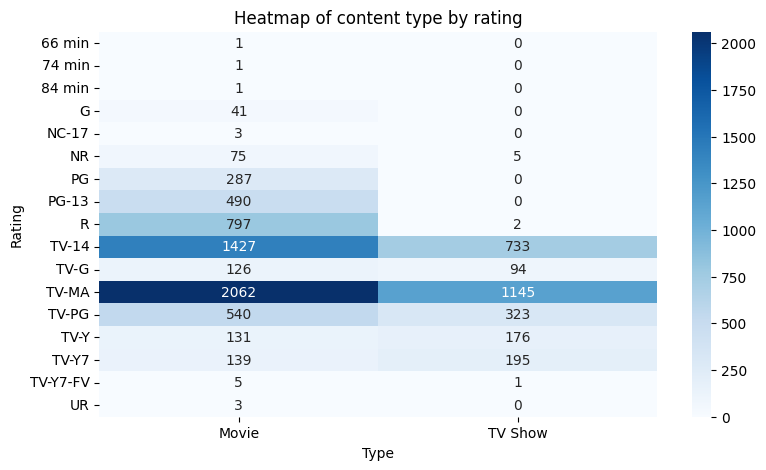

In [94]:
# Create a visualization to show the distribution of content type by rating on Netflix using seaborn's heatmap function
 

# Create a pivot table, since heatmap does not work directly on raw data

# Create a pivot table to count the number of titles for each combination of rating and type
pivot = df.pivot_table(index='rating', 
                       columns='type', 
                       values='title', 
                       aggfunc='count'
                       )

# Handle missing values

# Handle missing values by filling them with 0, since we want to show the count of titles for each ccombination of rating and type, even if there are no title
pivot = pivot.fillna(0)

# create heatmap
plt.figure(figsize=(9, 5))

sns.heatmap(pivot, annot=True, fmt='g', cmap='Blues')

plt.title('Heatmap of content type by rating')
plt.xlabel('Type')
plt.ylabel('Rating')
           
plt.show()



**The heatmap shows that TV-MA and TV-14 are the most common ratings across both movies. and TV shows. Movie-specific ratings such as R, PG-13, and PG are concentrated almost entirely among movies, while TV-Y7 and TV-Y are more strongly represented among TV shows. The visualization also highlights three anomolous rating values(`74 min`, `84 min`, and `66 min`), which appear to be movie durations recorded in the rating column.**

**These values should be corrected or excluded before any audience segmentation or predictive modeling.**

## Key Insights from the Netflix catalog


**1. Format mix: Movies account for 69.6% of the Netflix catalog, making them substantially more prevalent than TV shows. This imbalance should be considered when comparing content types, as raw counts naturally favor movies.**

**2. Geographic concentration: The United States is the most frequently recorded country, followed by India and the United Kingdom. Since some titles are associated with multiple countries, a more detailed regional analysis would require splitting and normalizing multi-country entries.**

**3. Audience positioning: TV-MA and TV-14 together account for 60.9% of the catalog, suggesting a stronger representation of content classified for mature and teenage audiences. Rating comparisons should still distinguish between movies and TV shows because their classification systems differ.**

**4. Catalog expansion: The number of titles added to Netflix increased rapidly from 2016 and peaked in 2019. The lower count observed in 2021 should be interpreted cautiously, as the dataset may not represent a complete year.**

**5. Content profile: Drama is the most common first-listed genre, and the typical movie runtime is approximately 98 minutes. These characteristics provide useful variables for content segmentation but do not indicate audience demand or commercial peerformance.**

## Overall Conclusion

**This exploratory data analysis provides descriptive ingights into the composition and characteristics of the Netflix catalog included in this dataset. Since the data do not include viewership, subscriber engagement, production costs, or revenue, the findings should be interpreted as measures of catalog composition rather than popularity or business performance.**